# **Optimizing Two-Way partial AUC on Imbalanced CIFAR10 Dataset (SOTAs)**


**Author**: Dixian Zhu, Zhuoning Yuan, Gang Li, Tianbao Yang
**Version**: 1.4.0 

**Introduction**

In this tutorial, we will learn how to quickly train a ResNet18 model by optimizing **two way partial AUC (TPAUC)** score using our novel `tpAUC_KL_Loss` and `SOTAs` optimizer [[Ref]](https://proceedings.mlr.press/v162/zhu22g.html) method on a binary image classification task on Cifar10. After completion of this tutorial, you should be able to use LibAUC to train your own models on your own datasets.

**Reference**:
   
If you find this tutorial helpful in your work, please cite our [library paper](https://arxiv.org/abs/2306.03065) and the following papers:

```
@inproceedings{zhu2022auc,
              title={When auc meets dro: Optimizing partial auc for deep learning with non-convex convergence guarantee},
              author={Zhu, Dixian and Li, Gang and Wang, Bokun and Wu, Xiaodong and Yang, Tianbao},
              booktitle={International Conference on Machine Learning},
              pages={27548--27573},
              year={2022},
              organization={PMLR}
            }

```

# **Installing LibAUC**

Let’s start with installing our library here. In this tutorial, we will use the lastest version for LibAUC by using ``pip install -U``.

In [ ]:
!pip install -U libauc

# **Importing LibAUC**

In [1]:
from libauc.models import resnet18
from libauc.datasets import CIFAR10
from libauc.losses import tpAUC_KL_Loss
from libauc.optimizers import SOTAs
from libauc.utils import ImbalancedDataGenerator
from libauc.sampler import DualSampler # data resampling (for binary class)
from libauc.metrics import pauc_roc_score

import torch
from PIL import Image
import numpy as np
import torchvision.transforms as transforms
from torch.utils.data import Dataset

# **Reproducibility**

These functions limit the number of sources of randomness behaviors, such as model intialization, data shuffling, etcs. However, completely reproducible results are not guaranteed across PyTorch releases [[Ref]](https://pytorch.org/docs/stable/notes/randomness.html#:~:text=Completely%20reproducible%20results%20are%20not,even%20when%20using%20identical%20seeds.).

In [3]:
def set_all_seeds(SEED):
    # REPRODUCIBILITY
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_all_seeds(2023)

# **Image Dataset**

Now we define the data input pipeline such as data augmentations. In this tutorials, we use ``RandomCrop``, ``RandomHorizontalFlip``. The ``pos_index_map`` helps map global index to local index for reducing memory cost in loss function since we only need to track the indices for positive samples.



In [4]:
class ImageDataset(Dataset):
    def __init__(self, images, targets, image_size=32, crop_size=30, mode='train'):
        self.images = images.astype(np.uint8)
        self.targets = targets
        self.mode = mode
        self.transform_train = transforms.Compose([
                            transforms.ToTensor(),
                            transforms.RandomCrop((crop_size, crop_size), padding=None),
                            transforms.RandomHorizontalFlip(),
                            transforms.Resize((image_size, image_size)),
                            ])
        self.transform_test = transforms.Compose([
                           transforms.ToTensor(),
                           transforms.Resize((image_size, image_size)),
                            ])

        # for loss function
        self.pos_indices = np.flatnonzero(targets==1)
        self.pos_index_map = {}
        for i, idx in enumerate(self.pos_indices):
            self.pos_index_map[idx] = i

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        target = self.targets[idx]
        image = Image.fromarray(image.astype('uint8'))
        if self.mode == 'train':
            idx = self.pos_index_map[idx] if idx in self.pos_indices else -1
            image = self.transform_train(image)
        else:
            image = self.transform_test(image)
        return image, target, idx

# **HyperParameters**

In [5]:
# HyperParameters
SEED = 123
batch_size = 64
total_epochs = 60
weight_decay = 2e-4
lr = 1e-3
decay_epochs = [30, 45]
decay_factor = 10

gamma0 = 0.5 # learning rate for control negative samples weights
gamma1 = 0.5 # learning rate for control positive samples weights

tau = 1.0 # KL-DRO regularization for outer positive samples part  #
Lambda = 0.5 # KL-DRO regularization for inner negative samples part #
load_pretrain = False

# **Loading datasets**

In [6]:
# load data as numpy arrays
train_data, train_targets = CIFAR10(root='./data', train=True).as_array()
test_data, test_targets  = CIFAR10(root='./data', train=False).as_array()

# generate imbalanced data
imratio = 0.2
generator = ImbalancedDataGenerator(shuffle=True, verbose=True, random_seed=2023)
(train_images, train_labels) = generator.transform(train_data, train_targets, imratio=imratio)
(test_images, test_labels) = generator.transform(test_data, test_targets, imratio=imratio)

# data augmentations
trainDataset = ImageDataset(train_images, train_labels)
testDataset = ImageDataset(test_images, test_labels, mode='test')

Files already downloaded and verified
Files already downloaded and verified
#SAMPLES: 31250, CLASS 0.0 COUNT: 25000, CLASS RATIO: 0.8000
#SAMPLES: 31250, CLASS 1.0 COUNT: 6250, CLASS RATIO: 0.2000
#SAMPLES: 6250, CLASS 0.0 COUNT: 5000, CLASS RATIO: 0.8000
#SAMPLES: 6250, CLASS 1.0 COUNT: 1250, CLASS RATIO: 0.2000


# **Pretraining (Recommended)**

Following the original [paper](https://proceedings.mlr.press/v162/zhu22g.html), it's recommended to start from a pretrained checkpoint with cross-entropy loss to significantly boost models' performance. It includes a pre-training step with standard cross-entropy loss, and a Partial AUC maximization step that maximizes a Partial AUC surrogate loss of the pre-trained model.

In [7]:
from torch.optim import Adam
import warnings
warnings.filterwarnings('ignore')

load_pretrain = True
model = resnet18(pretrained=False, num_classes=1, last_activation=None)
model = model.cuda()

loss_fn = torch.nn.BCELoss()
optimizer =Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

trainloader = torch.utils.data.DataLoader(trainDataset, batch_size=batch_size, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testDataset, batch_size=batch_size, shuffle=False, num_workers=2)


best_test = 0
for epoch in range(total_epochs):
    if epoch in decay_epochs:
        for param_group in optimizer.param_groups:
            param_group['lr'] = 0.1 * param_group['lr']

    model.train()
    for idx, (data, targets, index) in enumerate(trainloader):
        data, targets, index  = data.cuda(), targets.cuda(), index.cuda()
        y_pred = model(data)
        y_prob = torch.sigmoid(y_pred)
        loss = loss_fn(y_prob, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    ######***evaluation***####
    # evaluation on test sets
    model.eval()
    test_pred_list, test_true_list = [], []
    with torch.no_grad():
        for j, data in enumerate(testloader):
            test_data, test_targets, _ = data
            test_data = test_data.cuda()
            y_pred = model(test_data)
            y_prob = torch.sigmoid(y_pred)
            test_pred_list.append(y_prob.cpu().detach().numpy())
            test_true_list.append(test_targets.numpy())
    test_true = np.concatenate(test_true_list)
    test_pred = np.concatenate(test_pred_list)

    test_pauc = pauc_roc_score(test_true, test_pred, max_fpr = 0.3, min_tpr=0.7)
    if best_test < test_pauc:
        best_test = test_pauc
        torch.save(model.state_dict(), 'ce_pretrained_model_sotas.pth')

    model.train()
    print("epoch: %s, test_pauc: %.4f, best_test_pauc: %.4f, lr: %.4f"%(epoch, test_pauc, best_test, optimizer.param_groups[0]['lr'] ))

epoch: 0, test_pauc: 0.0000, best_test_pauc: 0.0000, lr: 0.0010
epoch: 1, test_pauc: 0.0000, best_test_pauc: 0.0000, lr: 0.0010
epoch: 2, test_pauc: 0.0000, best_test_pauc: 0.0000, lr: 0.0010
epoch: 3, test_pauc: 0.0015, best_test_pauc: 0.0015, lr: 0.0010
epoch: 4, test_pauc: 0.0000, best_test_pauc: 0.0015, lr: 0.0010
epoch: 5, test_pauc: 0.0006, best_test_pauc: 0.0015, lr: 0.0010
epoch: 6, test_pauc: 0.0462, best_test_pauc: 0.0462, lr: 0.0010
epoch: 7, test_pauc: 0.0452, best_test_pauc: 0.0462, lr: 0.0010
epoch: 8, test_pauc: 0.0648, best_test_pauc: 0.0648, lr: 0.0010
epoch: 9, test_pauc: 0.0502, best_test_pauc: 0.0648, lr: 0.0010
epoch: 10, test_pauc: 0.0223, best_test_pauc: 0.0648, lr: 0.0010
epoch: 11, test_pauc: 0.1365, best_test_pauc: 0.1365, lr: 0.0010
epoch: 12, test_pauc: 0.1835, best_test_pauc: 0.1835, lr: 0.0010
epoch: 13, test_pauc: 0.1504, best_test_pauc: 0.1835, lr: 0.0010
epoch: 14, test_pauc: 0.1309, best_test_pauc: 0.1835, lr: 0.0010
epoch: 15, test_pauc: 0.1324, best_

# **Optimizing pAUC Loss with SOTAs**

In [8]:
# oversampling minority class, you can tune it in (0, 0.5]
# e.g., sampling_rate=0.5 is that num of positive samples in mini-batch is sampling_rate*batch_size=32
sampling_rate = 0.5
num_pos = round(sampling_rate*batch_size)
num_neg = batch_size - num_pos

# dataloaders
sampler = DualSampler(trainDataset, batch_size, sampling_rate=sampling_rate)
trainloader = torch.utils.data.DataLoader(trainDataset, batch_size, sampler=sampler, shuffle=False, num_workers=1)
testloader = torch.utils.data.DataLoader(testDataset, batch_size=batch_size, shuffle=False, num_workers=1)

# **Creating models & TPAUC Optimizer**

In [9]:
# You can include sigmoid/l2 activations on model's outputs before computing loss
model = resnet18(pretrained=False, num_classes=1, last_activation=None)
model = model.cuda()
# load pretrained model
if load_pretrain:
    PATH = 'ce_pretrained_model_sotas.pth'
    state_dict = torch.load(PATH)
    filtered = {k:v for k,v in state_dict.items() if 'fc' not in k}
    msg = model.load_state_dict(filtered, False)
    print(msg)
    model.fc.reset_parameters()


# Initialize the loss function and optimizer
loss_fn = tpAUC_KL_Loss(data_len=sampler.pos_len, Lambda=Lambda, tau=tau, gammas=(gamma0, gamma1))
optimizer = SOTAs(model.parameters(), loss_fn=loss_fn, mode='adam', lr=lr, weight_decay=weight_decay)

_IncompatibleKeys(missing_keys=['fc.weight', 'fc.bias'], unexpected_keys=[])


# **Training**

In [10]:
import warnings
warnings.filterwarnings("ignore")
print ('Start Training')
print ('-'*30)

tr_tpAUC=[]
te_tpAUC=[]
best_test = 0
for epoch in range(total_epochs):
    if epoch in decay_epochs:
        optimizer.update_lr(decay_factor=decay_factor)

    train_loss = 0
    model.train()
    for idx, data in enumerate(trainloader):
        train_data, train_labels, index = data
        train_data, train_labels = train_data.cuda(), train_labels.cuda()
        y_pred = model(train_data)
        y_prob = torch.sigmoid(y_pred)
        loss = loss_fn(y_prob, train_labels, index[:num_pos])
        train_loss = train_loss  + loss.cpu().detach().numpy()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    train_loss = train_loss/(idx+1)

    # evaluation
    model.eval()
    with torch.no_grad():
        train_pred = []
        train_true = []
        for jdx, data in enumerate(trainloader):
            train_data, train_labels,_ = data
            train_data = train_data.cuda()
            y_pred = model(train_data)
            y_prob = torch.sigmoid(y_pred)
            train_pred.append(y_prob.cpu().detach().numpy())
            train_true.append(train_labels.numpy())
        train_true = np.concatenate(train_true)
        train_pred = np.concatenate(train_pred)
        single_train_auc =  pauc_roc_score(train_true, train_pred, max_fpr = 0.3, min_tpr=0.7)

        test_pred = []
        test_true = []
        for jdx, data in enumerate(testloader):
            test_data, test_labels, _ = data
            test_data = test_data.cuda()
            y_pred = model(test_data)
            y_prob = torch.sigmoid(y_pred)
            test_pred.append(y_prob.cpu().detach().numpy())
            test_true.append(test_labels.numpy())
        test_true = np.concatenate(test_true)
        test_pred = np.concatenate(test_pred)
        single_test_auc =  pauc_roc_score(test_true, test_pred, max_fpr = 0.3, min_tpr=0.7)
        if best_test < single_test_auc:
            best_test = single_test_auc
        print('Epoch=%s, Loss=%0.4f, Train_tpAUC(0.3,0.7)=%.4f, Test_tpAUC(0.3,0.7)=%.4f, best_test_tpAUC(0.3,0.7)=%.4f, lr=%.4f'%(epoch, train_loss, single_train_auc, single_test_auc, best_test, optimizer.lr))

        tr_tpAUC.append(single_train_auc)
        te_tpAUC.append(single_test_auc)

Start Training
------------------------------
Epoch=0, Loss=0.7628, Train_tpAUC(0.3,0.7)=0.7341, Test_tpAUC(0.3,0.7)=0.2721, best_test_tpAUC(0.3,0.7)=0.2721, lr=0.0010
Epoch=1, Loss=0.5182, Train_tpAUC(0.3,0.7)=0.6524, Test_tpAUC(0.3,0.7)=0.2818, best_test_tpAUC(0.3,0.7)=0.2818, lr=0.0010
Epoch=2, Loss=0.5169, Train_tpAUC(0.3,0.7)=0.7698, Test_tpAUC(0.3,0.7)=0.3181, best_test_tpAUC(0.3,0.7)=0.3181, lr=0.0010
Epoch=3, Loss=0.5033, Train_tpAUC(0.3,0.7)=0.5182, Test_tpAUC(0.3,0.7)=0.1445, best_test_tpAUC(0.3,0.7)=0.3181, lr=0.0010
Epoch=4, Loss=0.4877, Train_tpAUC(0.3,0.7)=0.6632, Test_tpAUC(0.3,0.7)=0.2664, best_test_tpAUC(0.3,0.7)=0.3181, lr=0.0010
Epoch=5, Loss=0.4704, Train_tpAUC(0.3,0.7)=0.8082, Test_tpAUC(0.3,0.7)=0.2863, best_test_tpAUC(0.3,0.7)=0.3181, lr=0.0010
Epoch=6, Loss=0.4462, Train_tpAUC(0.3,0.7)=0.6510, Test_tpAUC(0.3,0.7)=0.2124, best_test_tpAUC(0.3,0.7)=0.3181, lr=0.0010
Epoch=7, Loss=0.4429, Train_tpAUC(0.3,0.7)=0.8420, Test_tpAUC(0.3,0.7)=0.3087, best_test_tpAUC(0.3,0

# **Visualization**

Now, let's see the learning curves for optimizing two way pAUC from scratch and from a pretrained model with cross entropy loss.

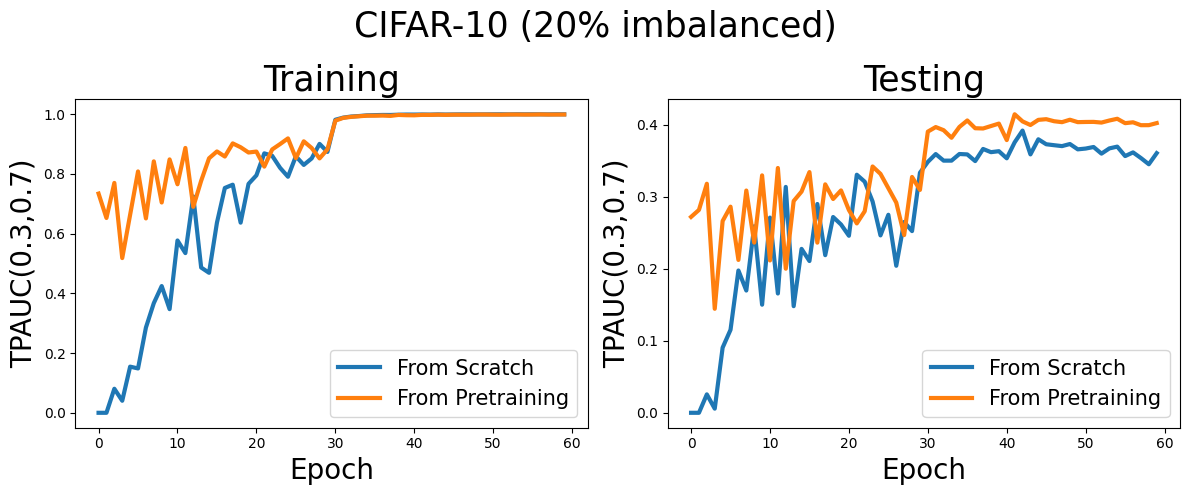

In [3]:
import matplotlib.pyplot as plt
import numpy as np
tr_tpAUC=[0.7340686421865071, 0.6523861417725976, 0.7697571757554482, 0.5181640862209829, 0.6632382487913021, 0.8082231370883574, 0.6509505406652053, 0.8419906017793952, 0.7042755724457082, 0.8485929759094291, 0.7652266175576936, 0.8868674039937814, 0.6897615571140835, 0.7768915847106662, 0.8523286213213361, 0.8752236481519994, 0.8581668457369729, 0.9021540891388055, 0.8892498033262324, 0.8716549717783728, 0.8747909107228096, 0.8243974955960515, 0.8819449923909647, 0.89989779260777, 0.9189142622615254, 0.8526040037279257, 0.9091358833770271, 0.8867607782454089, 0.8518731606635959, 0.8822833594960255, 0.9782023583634041, 0.9876358422173004, 0.9909971902527791, 0.9930102103870361, 0.9949333159065591, 0.9949216118874699, 0.9953726790912358, 0.9942961672503617, 0.997483689257653, 0.9965499735645696, 0.9962329244942777, 0.9977584491100356, 0.9976834402217404, 0.9982931164501517, 0.9977569194054131, 0.9983236393935511, 0.9982740129296326, 0.9983406262297669, 0.99876796522462, 0.9988299360490974, 0.9984605657445348, 0.9982824796668458, 0.9989244575649622, 0.9989117396718792, 0.998685361175001, 0.9987890609186011, 0.9991992885663972, 0.9987879047465028, 0.9987802206488635, 0.998913055929345]
te_tpAUC=[0.2720835555555555, 0.28182399999999996, 0.318144, 0.14448533333333333, 0.26637955555555554, 0.2863466666666667, 0.21235022222222222, 0.3087377777777778, 0.2363608888888889, 0.3297991111111111, 0.21162666666666666, 0.3400444444444444, 0.20017066666666666, 0.29414577777777773, 0.30727644444444446, 0.3343911111111111, 0.2363608888888889, 0.3173546666666667, 0.29697244444444443, 0.30892444444444445, 0.281632, 0.26309688888888894, 0.27994311111111114, 0.34215288888888895, 0.33189688888888885, 0.3119537777777778, 0.29198222222222225, 0.24688355555555558, 0.3276017777777777, 0.3095964444444444, 0.39057600000000003, 0.3969288888888889, 0.39256888888888886, 0.3820568888888889, 0.39707555555555557, 0.4060711111111111, 0.39528977777777774, 0.39492800000000006, 0.3983306666666666, 0.401728, 0.37883022222222223, 0.4146986666666667, 0.40477155555555555, 0.3997706666666666, 0.40691555555555553, 0.4078577777777778, 0.40501511111111116, 0.4037084444444444, 0.40711288888888886, 0.403744, 0.40399288888888885, 0.4041048888888889, 0.4031502222222223, 0.4060248888888889, 0.40843022222222225, 0.40232711111111114, 0.40354222222222225, 0.39950755555555556, 0.39955555555555555, 0.4024408888888889]

tr_tpAUC_scratch = [0.0, 0.0, 0.08050213763769921, 0.040334006379650914, 0.15452126257408305, 0.14852208121507784, 0.285387270694609, 0.3671972524228209, 0.42439337962338103, 0.3470672912083037, 0.57707256655478, 0.5347993927570692, 0.7244398719715495, 0.4864689355055898, 0.4687417578269827, 0.636698478356565, 0.7529223050215363, 0.7638683198955304, 0.6367875213954094, 0.7665590614330088, 0.7952058665808703, 0.8687836539463781, 0.8606273044733329, 0.8203095645457442, 0.7905463418323486, 0.8590389997126289, 0.8301345282721786, 0.8518168284015063, 0.9005089985408041, 0.8737030239272128, 0.9813676285046156, 0.9884804881906448, 0.992134579001453, 0.9937827023278047, 0.9961085381637468, 0.9967696284760136, 0.9973916935331416, 0.9972957668234957, 0.9982831022210528, 0.9987787443060302, 0.9986975810247185, 0.9989840982579795, 0.9986465849415449, 0.9992968161297178, 0.9988526325967533, 0.9991434098795156, 0.999431963754396, 0.9993364639390634, 0.9992874155611944, 0.9993348630853888, 0.9995505959053294, 0.9996459801034523, 0.9993523301777069, 0.9997270188739226, 0.9995369886490936, 0.9996679651605858, 0.9995451441092036, 0.9993488616614113, 0.9996902348139285, 0.9995364461375705]
te_tpAUC_scratch = [0.0, 0.0, 0.025589333333333335, 0.005740444444444445, 0.09052355555555555, 0.11532088888888889, 0.19768000000000002, 0.16982044444444444, 0.25902933333333333, 0.15017066666666665, 0.27112888888888886, 0.16573333333333334, 0.31376533333333334, 0.14812622222222221, 0.22768533333333335, 0.2108071111111111, 0.29003555555555555, 0.21898133333333336, 0.27193955555555555, 0.2615911111111111, 0.2459022222222222, 0.3306702222222222, 0.3210435555555555, 0.29353955555555555, 0.2464088888888889, 0.27508622222222223, 0.20425244444444446, 0.2650702222222222, 0.2524053333333333, 0.3334506666666667, 0.34853155555555554, 0.35939733333333335, 0.35027911111111104, 0.35027555555555556, 0.3594773333333333, 0.3589315555555555, 0.3496568888888889, 0.3664924444444444, 0.3620444444444445, 0.36339733333333335, 0.3535128888888889, 0.3757048888888889, 0.39203733333333335, 0.35895466666666664, 0.3799253333333333, 0.3730328888888889, 0.37171199999999993, 0.37044799999999994, 0.3733608888888889, 0.3659644444444444, 0.36706666666666665, 0.36921244444444445, 0.3599911111111111, 0.36727466666666664, 0.36972977777777777, 0.35660977777777775, 0.36172977777777776, 0.353872, 0.345256, 0.3606755555555555]

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12,5))
plt.suptitle('CIFAR-10 (20% imbalanced)',fontsize=25)

x=np.arange(len(tr_tpAUC))
ax0.plot(x, tr_tpAUC_scratch,  label='From Scratch', linewidth=3)
ax0.plot(x, tr_tpAUC,  label='From Pretraining', linewidth=3)
ax0.set_title('Training',fontsize=25)
ax1.plot(x, te_tpAUC_scratch, label='From Scratch', linewidth=3)
ax1.plot(x, te_tpAUC, label='From Pretraining', linewidth=3)
ax1.set_title('Testing',fontsize=25)

ax0.legend(fontsize=15)
ax1.legend(fontsize=15)
ax0.set_ylabel('TPAUC(0.3,0.7)', fontsize=20)
ax0.set_xlabel('Epoch', fontsize=20)
ax1.set_ylabel('TPAUC(0.3,0.7)', fontsize=20)
ax1.set_xlabel('Epoch', fontsize=20)

plt.tight_layout()
plt.savefig('sotas_p.png')